# 12h — Sector and Corporate Physical-Risk Exposure

S&P's sector-level physical-risk exposure/sensitivity scores under
different climate scenarios, Cline (2007)'s classic agricultural
GDP-impact-by-country estimates, Munich Re's 45-year natural catastrophe
loss record, and the EIOPA insurance-risk dashboard's country x peril
climate risk scores.

**Data note:** the S&P workbook has a 3-row merged/nested Excel header
(scenario group label, then Exposure-Risk/Sensitivity-Risk sub-group,
then the actual `Sector`/`DM`/`EM` column names). The real header row is
picked out directly with `header=2` (0-indexed) on `pandas.read_excel`.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

DATA_DIR = "../../data"

color_blue  = "#1f77b4"
color_red   = "#d62728"
color_green = "#2ca02c"

plt.rcParams["figure.dpi"] = 100


## 1. S&P 500 sector physical-risk exposure and sensitivity

Exposure-risk and sensitivity-risk scores (0-100 scale) by GICS sector,
separately for developed markets (DM) and emerging markets (EM), under 3
climate scenarios: Medium-warming 2030, Medium-warming 2050, and
High-warming 2050.


In [2]:
def load_snp_sheet(sheet):
    T = pd.read_excel(f"{DATA_DIR}/chap12_snp_physical_risk.xlsx", sheet_name=sheet, header=2)
    T.columns = ["Sector", "Weight_DM", "Weight_EM", "Exposure_DM", "Exposure_EM",
                 "Sensitivity_DM", "Sensitivity_EM"]
    return T


snp_med2030 = load_snp_sheet("Medium 2030")
snp_med2050 = load_snp_sheet("Medium 2050")
snp_high2050 = load_snp_sheet("High 2050")

sector = snp_med2030["Sector"]
exposure_sensitivity_cols = ["Exposure_DM", "Exposure_EM", "Sensitivity_DM", "Sensitivity_EM"]

combined = pd.concat([
    snp_med2030[exposure_sensitivity_cols].add_prefix("Medium2030_"),
    snp_med2050[exposure_sensitivity_cols].add_prefix("Medium2050_"),
    snp_high2050[exposure_sensitivity_cols].add_prefix("High2050_"),
], axis=1)
combined.insert(0, "Sector", sector)
display(combined.round(1))


,Sector,Medium2030_Exposure_DM,Medium2030_Exposure_EM,Medium2030_Sensitivity_DM,Medium2030_Sensitivity_EM,Medium2050_Exposure_DM,Medium2050_Exposure_EM,Medium2050_Sensitivity_DM,Medium2050_Sensitivity_EM,High2050_Exposure_DM,High2050_Exposure_EM,High2050_Sensitivity_DM,High2050_Sensitivity_EM
0,Communication Services,57.9,57.3,20.1,18.9,63.3,64.3,23.5,21.9,67.8,68.5,26.1,24.1
1,Consumer Discretionary,56.5,62.0,32.9,33.1,62.3,67.4,37.3,37.4,66.9,71.7,41.4,41.1
2,Consumer Staples,57.3,60.7,31.6,42.9,63.1,66.3,35.9,47.9,68.0,70.9,39.8,52.2
3,Energy,57.5,62.9,35.7,47.1,62.7,68.1,39.8,51.7,67.4,72.3,43.5,55.5
4,Financials,57.1,62.5,14.4,19.9,63.1,67.8,16.4,23.3,67.8,72.1,18.3,26.3
5,Health Care,57.4,59.0,22.6,41.7,63.3,64.9,26.0,47.0,68.0,69.4,28.9,51.1
6,Industrials,56.7,59.6,30.3,39.0,62.7,65.3,34.6,43.9,67.5,70.1,38.4,48.4
7,Information Technology,58.2,61.4,17.6,43.2,64.1,66.5,20.4,47.7,68.9,71.5,23.3,52.5
8,Materials,59.5,64.4,43.4,52.9,65.2,69.8,48.2,57.9,69.8,74.0,52.2,61.8
9,Real Estate,54.9,64.5,33.3,42.3,61.1,69.9,38.1,47.0,65.8,73.8,42.3,51.0


## 2. Cline (2007) agricultural GDP impact, with and without carbon fertilization

Cline's classic estimate of projected long-run agricultural GDP impact by
country (% change), comparing a "without carbon fertilization" scenario
(ignoring CO2's direct growth-boosting effect on crops) against a "with
carbon fertilization" scenario. 76 countries/regions. (The workbook's
sheet name is capitalized `Data`, not `data` — a case mismatch was caught
and fixed while loading it.)


In [3]:
cline = pd.read_excel(f"{DATA_DIR}/chap12_ext_cline_2007.xlsx", sheet_name="Data")
country = cline["Regions"]
x = cline["Without_CF"]
y = cline["With_CF"]

for label, z in [("Without carbon fertilization", x), ("With carbon fertilization", y), ("Difference (with - without)", y - x)]:
    print(f"{label}: mean={z.mean():.2f}, min={z.min():.2f} ({country[z.idxmin()]}), max={z.max():.2f} ({country[z.idxmax()]})")

n = len(country) // 2
table = pd.DataFrame({
    "Region (1st half)": country.iloc[:n].values,
    "Without CF": x.iloc[:n].round(1).values,
    "With CF": y.iloc[:n].round(1).values,
    "Region (2nd half)": country.iloc[n:].values,
    "Without CF ": x.iloc[n:].round(1).values,
    "With CF ": y.iloc[n:].round(1).values,
})
display(table)


Without carbon fertilization: mean=-17.64, min=-56.08 (Sudan), max=27.62 (USA North Central)
With carbon fertilization: mean=-5.28, min=-49.50 (Sudan), max=46.76 (USA North Central)
Difference (with - without): mean=12.35, min=6.59 (Sudan), max=19.14 (USA North Central)


,Region (1st half),Without CF,With CF,Region (2nd half),Without CF,With CF
0,Afghanistan,-24.7,-13.4,Morocco,-39.0,-29.9
1,Algeria,-36.0,-26.4,Nepal,-17.3,-4.8
2,Argentina,-11.1,2.2,Netherlands,-7.0,6.9
3,Australia,-26.6,-15.6,New Zealand,2.2,17.5
4,Australia Central East,-23.4,-11.9,Niger,-34.1,-24.2
5,Australia Central West,-35.1,-25.4,North Korea,-7.3,6.6
6,Australia North,-41.4,-32.6,Pakistan,-30.4,-20.0
7,Australia South East,-12.2,0.9,Peru,-30.6,-20.2
8,Australia South West,-13.5,-0.5,Philippines,-23.4,-11.9
9,Bangladesh,-21.7,-9.9,Poland,-4.7,9.5


## 3. Companion difference table

A small 4x4 table with no labels or surrounding context beyond generic
row/column data — plausibly a related illustrative comparison sitting
alongside the carbon-fertilization material above, but nothing ties down
what the rows/columns represent. Reproduced exactly as computed, without
inventing labels that aren't actually there.


In [4]:
data = np.array([
    [4.9, 1.3, -6.4, -24.1],
    [5.0, 9.9, 8.8, 17.5],
    [6.5, 15.3, 2.0, -2.1],
    [7.7, 23.3, 3.4, 1.7],
])
print("Raw 4x4 table:")
display(pd.DataFrame(data, columns=["Col 1", "Col 2", "Col 3", "Col 4"]))

diff = np.column_stack([data[:, 2] - data[:, 0], data[:, 3] - data[:, 1]])
print("Difference table ([Col3 - Col1, Col4 - Col2]):")
display(pd.DataFrame(diff, columns=["Col3 - Col1", "Col4 - Col2"]))


Raw 4x4 table:


,Col 1,Col 2,Col 3,Col 4
0,4.9,1.3,-6.4,-24.1
1,5.0,9.9,8.8,17.5
2,6.5,15.3,2.0,-2.1
3,7.7,23.3,3.4,1.7


Difference table ([Col3 - Col1, Col4 - Col2]):


,Col3 - Col1,Col4 - Col2
0,-11.3,-25.4
1,3.8,7.6
2,-4.5,-17.4
3,-4.3,-21.6


## 4. Munich Re natural catastrophe losses, 1980-2024

45 years of global natural-catastrophe losses (Munich Re NatCatSERVICE):
insured vs. uninsured portions stacked, with a 10-year trailing moving
average of total losses overlaid.


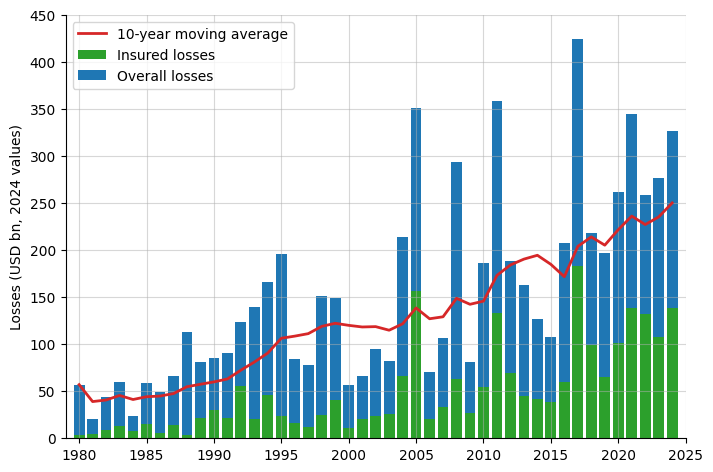

In [5]:
munich = pd.read_excel(f"{DATA_DIR}/chap12_ext_munich_re.xlsx", sheet_name="Feuil1")
year = munich["year"]
insured = munich["insured_loss"]
uninsured = munich["total_loss"] - munich["insured_loss"]
y_mean = munich["total_loss"].rolling(window=11, min_periods=1).mean()  # trailing 10 years + current

fig, ax = plt.subplots(figsize=(8, 5.5))
ax.bar(year, insured, color=color_green, label="Insured losses")
ax.bar(year, uninsured, bottom=insured, color=color_blue, label="Overall losses")
ax.plot(year, y_mean, "-", color=color_red, linewidth=2.0, label="10-year moving average")

ax.set_xlim(1979, 2025)
ax.set_xticks(range(1980, 2026, 5))
ax.set_ylim(0, 450)
ax.set_yticks(range(0, 451, 50))
ax.grid(True, alpha=0.5)
ax.legend(fontsize=10, loc="upper left")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.set_ylabel("Losses (USD bn, 2024 values)")
plt.show()


## 5. Munich Re losses by historical sub-period

Total, insured, and uninsured losses aggregated over a set of notable
historical windows (each decade, the full 1980-2024 period, and 5 more
recent multi-year windows), with the uninsured ("protection gap") share
of total losses.


In [6]:
selected_begin = [1980, 1990, 2000, 2010, 2020, 1980, 2005, 2011, 2017, 2021, 2024]
selected_end   = [1989, 1999, 2009, 2019, 2024, 2024, 2005, 2011, 2017, 2021, 2024]

rows = []
for b, e in zip(selected_begin, selected_end):
    mask = (year >= b) & (year <= e)
    total = munich.loc[mask, "total_loss"].sum()
    ins = munich.loc[mask, "insured_loss"].sum()
    uninsured_sum = total - ins
    rows.append([b, e, total, ins, uninsured_sum, 100 * uninsured_sum / total])

periods = pd.DataFrame(rows, columns=["From", "To", "Total loss", "Insured loss", "Uninsured loss", "Uninsured share (%)"])
display(periods.round(1))


,From,To,Total loss,Insured loss,Uninsured loss,Uninsured share (%)
0,1980,1989,574,96.1,477.9,83.3
1,1990,1999,1263,293.0,970.0,76.8
2,2000,2009,1417,448.0,969.0,68.4
3,2010,2019,2176,790.0,1386.0,63.7
4,2020,2024,1470,617.0,853.0,58.0
5,1980,2024,6900,2244.1,4655.9,67.5
6,2005,2005,351,157.0,194.0,55.3
7,2011,2011,358,133.0,225.0,62.8
8,2017,2017,424,183.0,241.0,56.8
9,2021,2021,345,138.0,207.0,60.0


## 6. EIOPA climate risk dashboard scores by country and peril

The EIOPA insurance-risk dashboard's physical-risk scores (0 = low risk)
for 31 European countries across 5 perils (coastal flood, earthquake,
river flood, wildfire, windstorm): the historical score (max across the
2022-2025 database vintages) and the current/estimated 2025 score, plus
a total-across-perils column. A `-9` sentinel marks "not applicable" (a
peril with no meaningful exposure for that country, e.g. coastal flood
for a landlocked country).


In [7]:
eiopa = pd.read_excel(f"{DATA_DIR}/chap12_ext_eiopa_dashboard.xlsx", sheet_name="Sheet1")
countries = sorted(eiopa["Country"].unique())
hazards = sorted(eiopa["Peril"].unique())

historical = pd.DataFrame(index=countries, columns=hazards, dtype=float)
current = pd.DataFrame(index=countries, columns=hazards, dtype=float)
for c in countries:
    for h in hazards:
        sub = eiopa[(eiopa["Country"] == c) & (eiopa["Peril"] == h)]
        historical.loc[c, h] = sub["Historical_score"].max()
        current.loc[c, h] = sub.loc[sub["DB_version"] == 2025, "Estimated_score"].iloc[0]

historical = historical.replace(-9, np.nan)
current = current.replace(-9, np.nan)

results = pd.concat([historical.add_prefix("Hist_"), current.add_prefix("2025_")], axis=1)
results["Total (2025)"] = current.sum(axis=1)
display(results.round(1))
print("Perils:", hazards)


,Hist_Coastal Flood,Hist_Earthquake,Hist_Flood*,Hist_Wildfire,Hist_Windstorm,2025_Coastal Flood,2025_Earthquake,2025_Flood*,2025_Wildfire,2025_Windstorm,Total (2025)
Austria,NaN,1.0,3.0,NaN,2.0,0.0,2.0,2.5,2.5,1.0,8.0
Belgium,NaN,1.5,2.5,NaN,2.0,1.0,1.0,1.5,1.0,1.5,6.0
Bulgaria,NaN,1.5,3.0,1.5,2.5,1.5,3.0,2.5,1.5,1.5,10.0
Croatia,NaN,3.5,3.0,2.5,2.0,1.5,3.0,3.0,2.5,1.0,11.0
Cyprus,NaN,1.5,NaN,1.0,2.0,1.0,2.5,1.0,2.5,1.0,8.0
Czechia,NaN,1.0,2.5,1.0,2.5,0.0,1.0,2.5,1.0,1.5,6.0
Denmark,1.0,NaN,1.0,NaN,2.0,1.0,0.0,1.0,1.0,2.0,5.0
EEA,1.0,2.5,3.0,1.5,2.0,1.0,1.0,1.5,1.0,1.0,5.5
Estonia,NaN,NaN,1.0,NaN,2.5,1.0,0.0,1.0,1.0,1.0,4.0
Finland,1.0,NaN,2.0,NaN,1.0,1.0,0.0,1.0,1.0,1.0,4.0


Perils: ['Coastal Flood', 'Earthquake', 'Flood*', 'Wildfire', 'Windstorm']
